In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pipeline as pipeline
import copy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print(pipeline.__file__)

/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/model/spline.py
/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/model/priors.py
/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/model/age_groups.py
/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/model/covariates.py
/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/model/likelihood.py
/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/pipeline.py


In [3]:
import os

def list_all_csv_files(dir_path):
    """
    주어진 dir_path 아래의 모든 하위 디렉토리를 포함하여
    .csv 확장자를 가진 파일의 전체 경로를 리스트로 반환합니다.
    """
    csv_files = []
    for root, dirs, files in os.walk(dir_path):
        for file in files:
            if file.lower().endswith('.csv'):
                csv_files.append(os.path.join(root, file))
    return csv_files

dir_path = './data_ready/input_data/NR'
csv_files = list_all_csv_files(dir_path)
csv_files


['./data_ready/input_data/NR/joined_input_data_NR_Early.csv',
 './data_ready/input_data/NR/joined_input_data_NR_Late-dry.csv',
 './data_ready/input_data/NR/joined_input_data_NR_Intermediate.csv',
 './data_ready/input_data/NR/joined_input_data_NR_Late-wet.csv']

In [4]:
basedir = '/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/data_ready/params'

output_template_path = f'{basedir}/output_template.csv'
detailed_pop_path=f'{basedir}/pop_detailed.csv'
parameters_path = f'{basedir}/parameters.jsonc'
hierarchy_path = f'{basedir}/hierarchy.json' 

In [42]:
def plot_global_triple_trend(
    df: pd.DataFrame,
    save_path: str = "global_triple_trend.png",
    percent=True,
    cases_unit=1e6
):
    gdf = df[df["level"] == 0].copy()

    counts = gdf["year"].value_counts()
    duplicates = counts[counts > 1]
    if not duplicates.empty:
        raise ValueError(f"Global rows have duplicate years: {duplicates.index.tolist()}")

    required_cols = [
        "year",
        "mean_prev","lower_prev","upper_prev",
        "mean_prev_std","lower_prev_std","upper_prev_std",
        "mean_cases","lower_cases","upper_cases"
    ]
    missing = [c for c in required_cols if c not in gdf.columns]
    if missing:
        raise KeyError(f"Missing columns in df: {missing}")

    agg = gdf.sort_values("year")[required_cols].reset_index(drop=True)

    scale = 100.0 if percent else 1.0
    years = agg["year"].to_numpy()

    y_prev      = agg["mean_prev"].to_numpy() * scale
    y_prev_lo   = agg["lower_prev"].to_numpy() * scale
    y_prev_hi   = agg["upper_prev"].to_numpy() * scale

    y_prev_std    = agg["mean_prev_std"].to_numpy() * scale
    y_prev_std_lo = agg["lower_prev_std"].to_numpy() * scale
    y_prev_std_hi = agg["upper_prev_std"].to_numpy() * scale

    y_cases      = agg["mean_cases"].to_numpy() / cases_unit
    y_cases_lo   = agg["lower_cases"].to_numpy() / cases_unit
    y_cases_hi   = agg["upper_cases"].to_numpy() / cases_unit

    # 색상 팔레트에서 3가지 색 선택
    colors = plt.get_cmap("tab10").colors
    c1, c2, c3 = colors[0], colors[1], colors[2]

    fig, ax = plt.subplots(figsize=(8.5, 5))

    # 유병률
    line1, = ax.plot(years, y_prev, linewidth=2, color=c1, label="Prevalence")
    ax.fill_between(years, y_prev_lo, y_prev_hi, alpha=0.2, linewidth=0, color=c1)

    # 표준화 유병률
    line2, = ax.plot(years, y_prev_std, linewidth=2, linestyle="--", color=c2, label="Standardized prevalence")
    ax.fill_between(years, y_prev_std_lo, y_prev_std_hi, alpha=0.15, linewidth=0, color=c2)

    ax.set_xlabel("Year")
    ax.set_ylabel(f"Prevalence ({'%' if percent else 'per 1'})")
    ax.grid(True, alpha=0.3)

    # 절대 환자수
    ax2 = ax.twinx()
    line3, = ax2.plot(years, y_cases, linewidth=2, color=c3, label=f"Cases (/{int(cases_unit):,})")
    ax2.fill_between(years, y_cases_lo, y_cases_hi, alpha=0.15, linewidth=0, color=c3)
    ax2.set_ylabel(f"Cases (× {int(cases_unit):,})")

    # 범례
    lines = [line1, line2, line3]
    labels = [ln.get_label() for ln in lines]
    ax.legend(lines, labels, loc="upper left")

    plt.title("Global AMD: Prevalence, Standardized Prevalence, and Cases Over Time")
    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()

Processing Early...
Standard errors replaced: 0
Effective sample sizes filled: 0


INFO:pipeline:  ▶ pm.find_MAP() 수행 중...


Multiprocess sampling (8 chains in 4 jobs)
INFO:pymc:Multiprocess sampling (8 chains in 4 jobs)
CompoundStep
INFO:pymc:CompoundStep
>Metropolis: [gamma_p]
INFO:pymc:>Metropolis: [gamma_p]
>Metropolis: [sigma_alpha_p_0_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_0_z]
>Metropolis: [sigma_alpha_p_1_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_1_z]
>Metropolis: [sigma_alpha_p_2_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_2_z]
>Metropolis: [sigma_alpha_p_3_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_3_z]
>Metropolis: [alpha_p_31]
INFO:pymc:>Metropolis: [alpha_p_31]
>Metropolis: [alpha_p_56]
INFO:pymc:>Metropolis: [alpha_p_56]
>Metropolis: [alpha_p_62]
INFO:pymc:>Metropolis: [alpha_p_62]
>Metropolis: [alpha_p_64]
INFO:pymc:>Metropolis: [alpha_p_64]
>Metropolis: [alpha_p_70]
INFO:pymc:>Metropolis: [alpha_p_70]
>Metropolis: [alpha_p_71]
INFO:pymc:>Metropolis: [alpha_p_71]
>Metropolis: [alpha_p_65]
INFO:pymc:>Metropolis: [alpha_p_65]
>Metropolis: [alpha_p_67]
INFO:pymc:>Metropolis: [alpha_p_67]
>Metropolis:

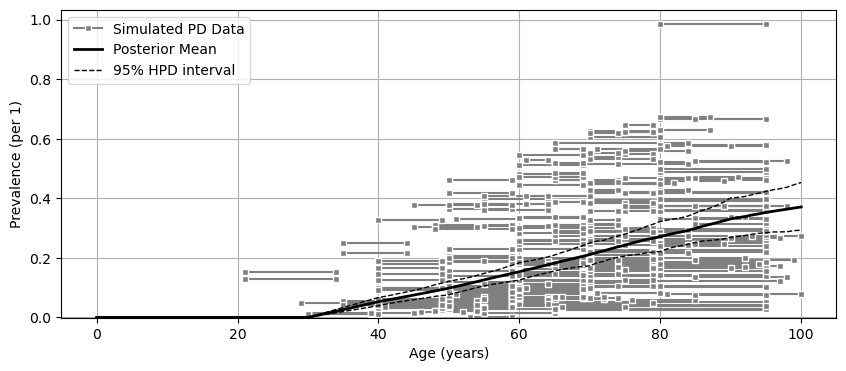

Saved summary to prevalence_2021_Early.csv
[world_predict] Saved 7232 rows to '1990_2021_Early_all_regions.csv'


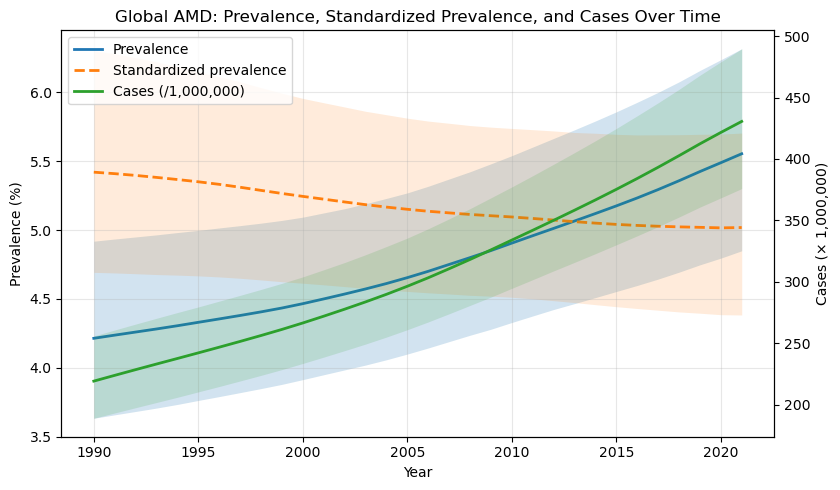

Processing Late-dry...
Standard errors replaced: 0
Effective sample sizes filled: 0


INFO:pipeline:  ▶ pm.find_MAP() 수행 중...


Multiprocess sampling (8 chains in 4 jobs)
INFO:pymc:Multiprocess sampling (8 chains in 4 jobs)
CompoundStep
INFO:pymc:CompoundStep
>Metropolis: [gamma_p]
INFO:pymc:>Metropolis: [gamma_p]
>Metropolis: [sigma_alpha_p_0_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_0_z]
>Metropolis: [sigma_alpha_p_1_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_1_z]
>Metropolis: [sigma_alpha_p_2_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_2_z]
>Metropolis: [sigma_alpha_p_3_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_3_z]
>Metropolis: [alpha_p_31]
INFO:pymc:>Metropolis: [alpha_p_31]
>Metropolis: [alpha_p_42]
INFO:pymc:>Metropolis: [alpha_p_42]
>Metropolis: [alpha_p_54]
INFO:pymc:>Metropolis: [alpha_p_54]
>Metropolis: [alpha_p_56]
INFO:pymc:>Metropolis: [alpha_p_56]
>Metropolis: [alpha_p_58]
INFO:pymc:>Metropolis: [alpha_p_58]
>Metropolis: [alpha_p_60]
INFO:pymc:>Metropolis: [alpha_p_60]
>Metropolis: [alpha_p_62]
INFO:pymc:>Metropolis: [alpha_p_62]
>Metropolis: [alpha_p_64]
INFO:pymc:>Metropolis: [alpha_p_64]
>Metropolis:

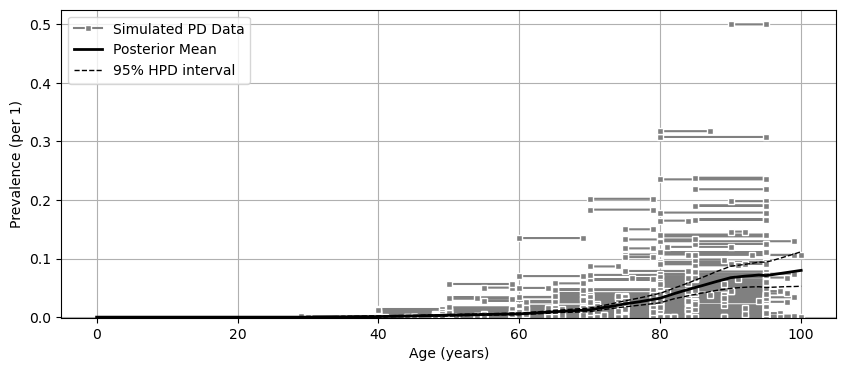

Saved summary to prevalence_2021_Late-dry.csv
[world_predict] Saved 7232 rows to '1990_2021_Late-dry_all_regions.csv'


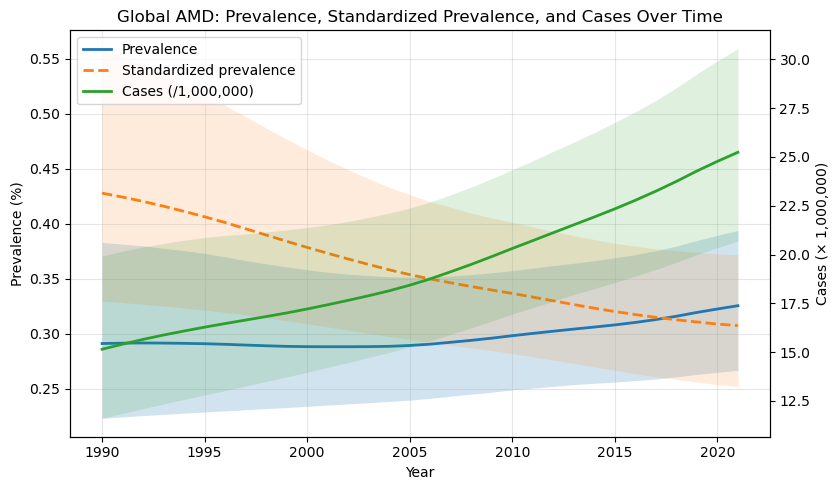

Processing Intermediate...
Standard errors replaced: 0
Effective sample sizes filled: 0


INFO:pipeline:  ▶ pm.find_MAP() 수행 중...


Multiprocess sampling (8 chains in 4 jobs)
INFO:pymc:Multiprocess sampling (8 chains in 4 jobs)
CompoundStep
INFO:pymc:CompoundStep
>Metropolis: [gamma_p]
INFO:pymc:>Metropolis: [gamma_p]
>Metropolis: [sigma_alpha_p_0_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_0_z]
>Metropolis: [sigma_alpha_p_1_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_1_z]
>Metropolis: [sigma_alpha_p_2_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_2_z]
>Metropolis: [sigma_alpha_p_3_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_3_z]
>Metropolis: [alpha_p_31]
INFO:pymc:>Metropolis: [alpha_p_31]
>Metropolis: [alpha_p_56]
INFO:pymc:>Metropolis: [alpha_p_56]
>Metropolis: [alpha_p_62]
INFO:pymc:>Metropolis: [alpha_p_62]
>Metropolis: [alpha_p_64]
INFO:pymc:>Metropolis: [alpha_p_64]
>Metropolis: [alpha_p_70]
INFO:pymc:>Metropolis: [alpha_p_70]
>Metropolis: [alpha_p_71]
INFO:pymc:>Metropolis: [alpha_p_71]
>Metropolis: [alpha_p_65]
INFO:pymc:>Metropolis: [alpha_p_65]
>Metropolis: [alpha_p_67]
INFO:pymc:>Metropolis: [alpha_p_67]
>Metropolis:

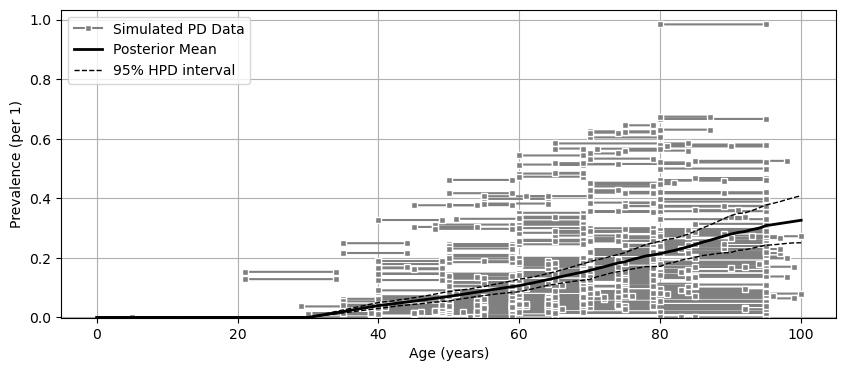

Saved summary to prevalence_2021_Intermediate.csv
[world_predict] Saved 7232 rows to '1990_2021_Intermediate_all_regions.csv'


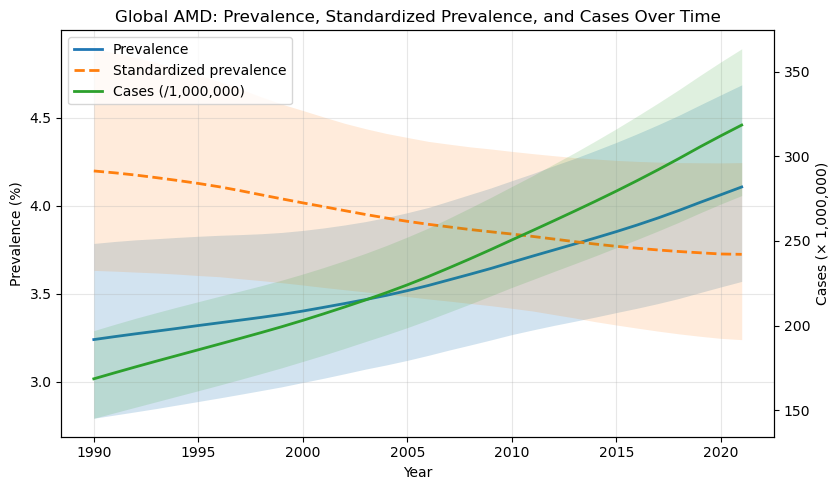

Processing Late-wet...
Standard errors replaced: 0
Effective sample sizes filled: 0


INFO:pipeline:  ▶ pm.find_MAP() 수행 중...


Multiprocess sampling (8 chains in 4 jobs)
INFO:pymc:Multiprocess sampling (8 chains in 4 jobs)
CompoundStep
INFO:pymc:CompoundStep
>Metropolis: [gamma_p]
INFO:pymc:>Metropolis: [gamma_p]
>Metropolis: [sigma_alpha_p_0_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_0_z]
>Metropolis: [sigma_alpha_p_1_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_1_z]
>Metropolis: [sigma_alpha_p_2_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_2_z]
>Metropolis: [sigma_alpha_p_3_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_3_z]
>Metropolis: [alpha_p_31]
INFO:pymc:>Metropolis: [alpha_p_31]
>Metropolis: [alpha_p_42]
INFO:pymc:>Metropolis: [alpha_p_42]
>Metropolis: [alpha_p_54]
INFO:pymc:>Metropolis: [alpha_p_54]
>Metropolis: [alpha_p_56]
INFO:pymc:>Metropolis: [alpha_p_56]
>Metropolis: [alpha_p_58]
INFO:pymc:>Metropolis: [alpha_p_58]
>Metropolis: [alpha_p_60]
INFO:pymc:>Metropolis: [alpha_p_60]
>Metropolis: [alpha_p_62]
INFO:pymc:>Metropolis: [alpha_p_62]
>Metropolis: [alpha_p_64]
INFO:pymc:>Metropolis: [alpha_p_64]
>Metropolis:

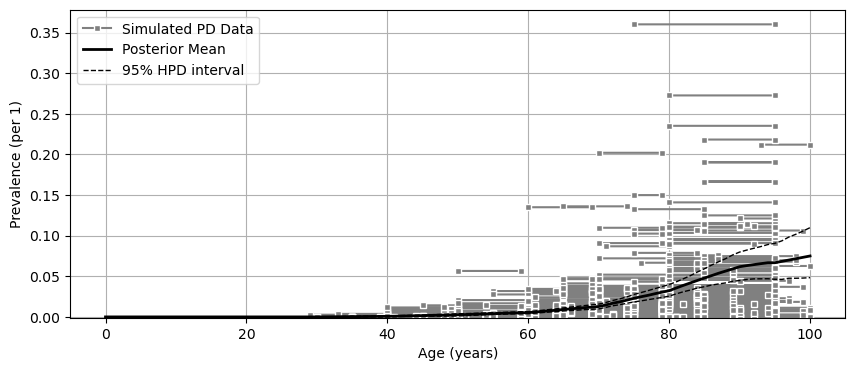

Saved summary to prevalence_2021_Late-wet.csv
[world_predict] Saved 7232 rows to '1990_2021_Late-wet_all_regions.csv'


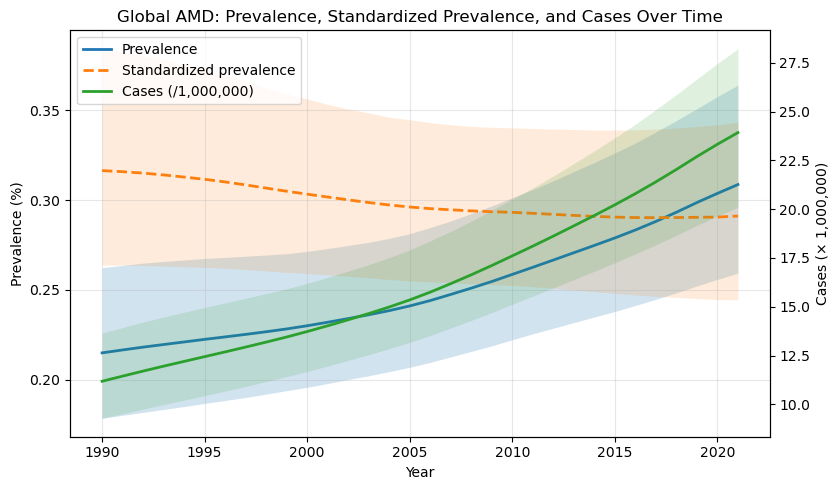

In [43]:
import os

for input_data_path in csv_files:
    stage = os.path.basename(input_data_path) \
                 .replace("joined_input_data_NR_", "") \
                 .replace(".csv","")   # → "Early", "Late-dry", ...
    
    print(f"Processing {stage}...")

    pm_model = pipeline.initiliaze_pipeline(
        input_data_path=input_data_path,
        output_template_path=output_template_path,
        parameters_path=parameters_path,
        hierarchy_path=hierarchy_path,
        detailed_pop_path=detailed_pop_path,
        verbose=False
    )

    rate_type = 'neg_binom'
    pipeline.generate_pymc_objects(pm_model, rate_type=rate_type, include_covariates=True)
    map_estimate = pipeline.return_map_estimate(pm_model=pm_model, verbose=False)
    idata = pipeline.return_idata(
        pm_model     = pm_model, 
        map_estimate = map_estimate, 
        draws        = 4000,
        tune         = 1000,
        chains       = 8,
        cores        = 4,
        target_accept= 0.9,
        max_treedepth= 10,
        use_advi     = False,
        use_metropolis=True,
        verbose=False
    ) 
    
    pred = pipeline.predict_for(
        pm_model            = pm_model,
        idata               = idata, 
        root_area           = 'Global',
        root_sex            = 'Both',
        root_year           = 'all',
        location_id         = 1,
        sex_name            = 'Both',
        year_id             = 2021,
        population_weighted = True,
        lower               = 0.0,
        upper               = 1.0,
        include_covariates  = True,
        return_scalar       = False
    )
    pipeline.visualize_pred(pred, pm_model.shared_data["data"])

    # === 2) 통계량 계산 ===
    mean_vals    = pred.mean(axis=0)
    lower_vals   = np.percentile(pred,  2.5, axis=0)
    upper_vals   = np.percentile(pred, 97.5, axis=0)

    ages = np.arange(pred.shape[1])  # 0,1,2,...,100
    df = pd.DataFrame({
        'mean'     : mean_vals,
        'lower_ci' : lower_vals,
        'upper_ci' : upper_vals
    }, index=ages)
    df.index.name = 'age'

    # === 4) 파일 저장 경로 ===
    out_path = f'prevalence_2021_{stage}.csv'
    df.to_csv(out_path)
    print(f"Saved summary to {out_path}")

    results = pipeline.world_predict(
        pm_model,
        idata,
        years=list(range(1990, 2022)),
        output_csv_path=f'1990_2021_{stage}_all_regions.csv'
    )

    plot_global_triple_trend(results, f"global_prev_trend_{stage}.png")


In [5]:
dir_path = './data_ready/input_data/ETH'
csv_files = list_all_csv_files(dir_path)
csv_files

['./data_ready/input_data/ETH/African/joined_input_data_African_ancestry_Late-dry.csv',
 './data_ready/input_data/ETH/African/joined_input_data_African_ancestry_Early to intermediate.csv',
 './data_ready/input_data/ETH/African/joined_input_data_African_ancestry_Intermediate.csv',
 './data_ready/input_data/ETH/African/joined_input_data_African_ancestry_Late-wet.csv',
 './data_ready/input_data/ETH/European/joined_input_data_European_ancestry_Late-dry.csv',
 './data_ready/input_data/ETH/European/joined_input_data_European_ancestry_Early.csv',
 './data_ready/input_data/ETH/European/joined_input_data_European_ancestry_Intermediate.csv',
 './data_ready/input_data/ETH/European/joined_input_data_European_ancestry_Late-wet.csv',
 './data_ready/input_data/ETH/Hispanic/joined_input_data_Hispanic_Intermediate.csv',
 './data_ready/input_data/ETH/Hispanic/joined_input_data_Hispanic_Early.csv',
 './data_ready/input_data/ETH/Hispanic/joined_input_data_Hispanic_Late-wet.csv',
 './data_ready/input_data/

[RUN] Group=African_ancestry | Stage=Late-dry (./data_ready/input_data/ETH/African/joined_input_data_African_ancestry_Late-dry.csv)
Standard errors replaced: 0
Effective sample sizes filled: 0


INFO:pipeline:  ▶ pm.find_MAP() 수행 중...


Multiprocess sampling (8 chains in 4 jobs)
INFO:pymc:Multiprocess sampling (8 chains in 4 jobs)
CompoundStep
INFO:pymc:CompoundStep
>Metropolis: [gamma_p]
INFO:pymc:>Metropolis: [gamma_p]
>Metropolis: [sigma_alpha_p_0_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_0_z]
>Metropolis: [sigma_alpha_p_1_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_1_z]
>Metropolis: [sigma_alpha_p_2_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_2_z]
>Metropolis: [sigma_alpha_p_3_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_3_z]
>Metropolis: [alpha_p_64]
INFO:pymc:>Metropolis: [alpha_p_64]
>Metropolis: [alpha_p_100]
INFO:pymc:>Metropolis: [alpha_p_100]
>Metropolis: [alpha_p_102]
INFO:pymc:>Metropolis: [alpha_p_102]
>Metropolis: [alpha_p_103]
INFO:pymc:>Metropolis: [alpha_p_103]
>Metropolis: [alpha_p_104]
INFO:pymc:>Metropolis: [alpha_p_104]
>Metropolis: [alpha_p_107]
INFO:pymc:>Metropolis: [alpha_p_107]
>Metropolis: [alpha_p_166]
INFO:pymc:>Metropolis: [alpha_p_166]
>Metropolis: [alpha_p_174]
INFO:pymc:>Metropolis: [alpha_p_174

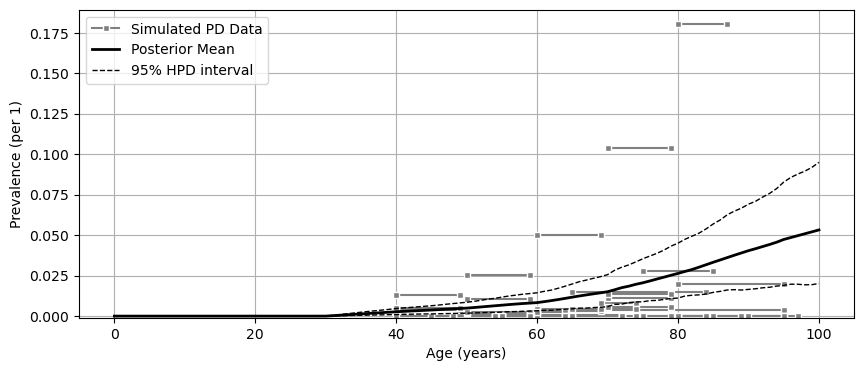

[SAVE] results/ETH/African_ancestry/Late-dry/age_curve_2021_African_ancestry_Late-dry.csv
[RUN] Group=African_ancestry | Stage=Early to intermediate (./data_ready/input_data/ETH/African/joined_input_data_African_ancestry_Early to intermediate.csv)
Standard errors replaced: 0
Effective sample sizes filled: 0


INFO:pipeline:  ▶ pm.find_MAP() 수행 중...


Multiprocess sampling (8 chains in 4 jobs)
INFO:pymc:Multiprocess sampling (8 chains in 4 jobs)
CompoundStep
INFO:pymc:CompoundStep
>Metropolis: [gamma_p]
INFO:pymc:>Metropolis: [gamma_p]
>Metropolis: [sigma_alpha_p_0_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_0_z]
>Metropolis: [sigma_alpha_p_1_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_1_z]
>Metropolis: [sigma_alpha_p_2_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_2_z]
>Metropolis: [sigma_alpha_p_3_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_3_z]
>Metropolis: [alpha_p_64]
INFO:pymc:>Metropolis: [alpha_p_64]
>Metropolis: [alpha_p_100]
INFO:pymc:>Metropolis: [alpha_p_100]
>Metropolis: [alpha_p_102]
INFO:pymc:>Metropolis: [alpha_p_102]
>Metropolis: [alpha_p_103]
INFO:pymc:>Metropolis: [alpha_p_103]
>Metropolis: [alpha_p_104]
INFO:pymc:>Metropolis: [alpha_p_104]
>Metropolis: [alpha_p_107]
INFO:pymc:>Metropolis: [alpha_p_107]
>Metropolis: [alpha_p_166]
INFO:pymc:>Metropolis: [alpha_p_166]
>Metropolis: [alpha_p_174]
INFO:pymc:>Metropolis: [alpha_p_174

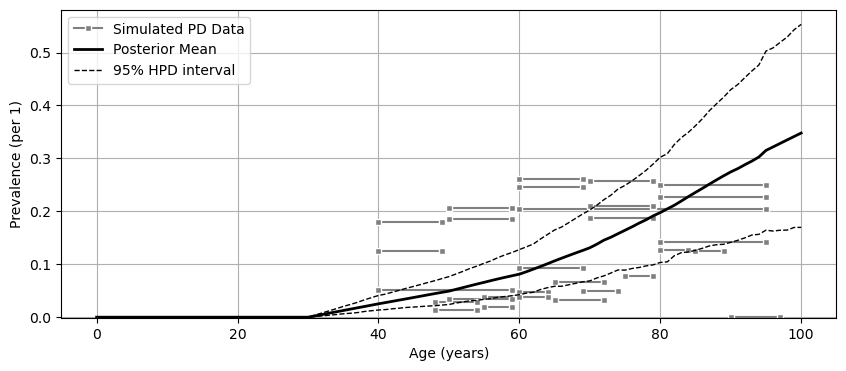

[SAVE] results/ETH/African_ancestry/Early-to-intermediate/age_curve_2021_African_ancestry_Early-to-intermediate.csv
[RUN] Group=African_ancestry | Stage=Intermediate (./data_ready/input_data/ETH/African/joined_input_data_African_ancestry_Intermediate.csv)
Standard errors replaced: 0
Effective sample sizes filled: 0


INFO:pipeline:  ▶ pm.find_MAP() 수행 중...


Multiprocess sampling (8 chains in 4 jobs)
INFO:pymc:Multiprocess sampling (8 chains in 4 jobs)
CompoundStep
INFO:pymc:CompoundStep
>Metropolis: [gamma_p]
INFO:pymc:>Metropolis: [gamma_p]
>Metropolis: [sigma_alpha_p_0_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_0_z]
>Metropolis: [sigma_alpha_p_1_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_1_z]
>Metropolis: [sigma_alpha_p_2_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_2_z]
>Metropolis: [sigma_alpha_p_3_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_3_z]
>Metropolis: [beta_p_x_lpa]
INFO:pymc:>Metropolis: [beta_p_x_lpa]
>Metropolis: [beta_p_x_sev]
INFO:pymc:>Metropolis: [beta_p_x_sev]
>Metropolis: [beta_p_x_sex]
INFO:pymc:>Metropolis: [beta_p_x_sex]
>Metropolis: [eta_p]
INFO:pymc:>Metropolis: [eta_p]
Sampling 8 chains for 1_000 tune and 4_000 draw iterations (8_000 + 32_000 draws total) took 17 seconds.
INFO:pymc:Sampling 8 chains for 1_000 tune and 4_000 draw iterations (8_000 + 32_000 draws total) took 17 seconds.
The rhat statistic is larger than 1.01

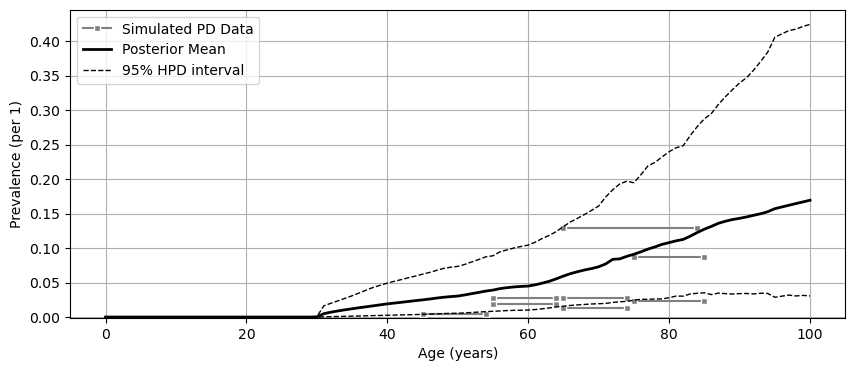

[SAVE] results/ETH/African_ancestry/Intermediate/age_curve_2021_African_ancestry_Intermediate.csv
[RUN] Group=African_ancestry | Stage=Late-wet (./data_ready/input_data/ETH/African/joined_input_data_African_ancestry_Late-wet.csv)
Standard errors replaced: 0
Effective sample sizes filled: 0


INFO:pipeline:  ▶ pm.find_MAP() 수행 중...


Multiprocess sampling (8 chains in 4 jobs)
INFO:pymc:Multiprocess sampling (8 chains in 4 jobs)
CompoundStep
INFO:pymc:CompoundStep
>Metropolis: [gamma_p]
INFO:pymc:>Metropolis: [gamma_p]
>Metropolis: [sigma_alpha_p_0_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_0_z]
>Metropolis: [sigma_alpha_p_1_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_1_z]
>Metropolis: [sigma_alpha_p_2_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_2_z]
>Metropolis: [sigma_alpha_p_3_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_3_z]
>Metropolis: [alpha_p_64]
INFO:pymc:>Metropolis: [alpha_p_64]
>Metropolis: [alpha_p_100]
INFO:pymc:>Metropolis: [alpha_p_100]
>Metropolis: [alpha_p_102]
INFO:pymc:>Metropolis: [alpha_p_102]
>Metropolis: [alpha_p_103]
INFO:pymc:>Metropolis: [alpha_p_103]
>Metropolis: [alpha_p_104]
INFO:pymc:>Metropolis: [alpha_p_104]
>Metropolis: [alpha_p_107]
INFO:pymc:>Metropolis: [alpha_p_107]
>Metropolis: [alpha_p_166]
INFO:pymc:>Metropolis: [alpha_p_166]
>Metropolis: [alpha_p_174]
INFO:pymc:>Metropolis: [alpha_p_174

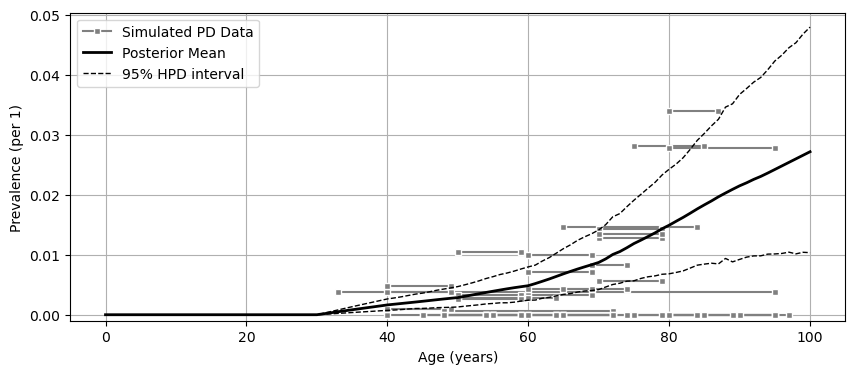

[SAVE] results/ETH/African_ancestry/Late-wet/age_curve_2021_African_ancestry_Late-wet.csv
[RUN] Group=European_ancestry | Stage=Late-dry (./data_ready/input_data/ETH/European/joined_input_data_European_ancestry_Late-dry.csv)
Standard errors replaced: 0
Effective sample sizes filled: 0


INFO:pipeline:  ▶ pm.find_MAP() 수행 중...


Multiprocess sampling (8 chains in 4 jobs)
INFO:pymc:Multiprocess sampling (8 chains in 4 jobs)
CompoundStep
INFO:pymc:CompoundStep
>Metropolis: [gamma_p]
INFO:pymc:>Metropolis: [gamma_p]
>Metropolis: [sigma_alpha_p_0_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_0_z]
>Metropolis: [sigma_alpha_p_1_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_1_z]
>Metropolis: [sigma_alpha_p_2_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_2_z]
>Metropolis: [sigma_alpha_p_3_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_3_z]
>Metropolis: [alpha_p_31]
INFO:pymc:>Metropolis: [alpha_p_31]
>Metropolis: [alpha_p_56]
INFO:pymc:>Metropolis: [alpha_p_56]
>Metropolis: [alpha_p_58]
INFO:pymc:>Metropolis: [alpha_p_58]
>Metropolis: [alpha_p_64]
INFO:pymc:>Metropolis: [alpha_p_64]
>Metropolis: [alpha_p_70]
INFO:pymc:>Metropolis: [alpha_p_70]
>Metropolis: [alpha_p_71]
INFO:pymc:>Metropolis: [alpha_p_71]
>Metropolis: [alpha_p_100]
INFO:pymc:>Metropolis: [alpha_p_100]
>Metropolis: [alpha_p_102]
INFO:pymc:>Metropolis: [alpha_p_102]
>Metropo

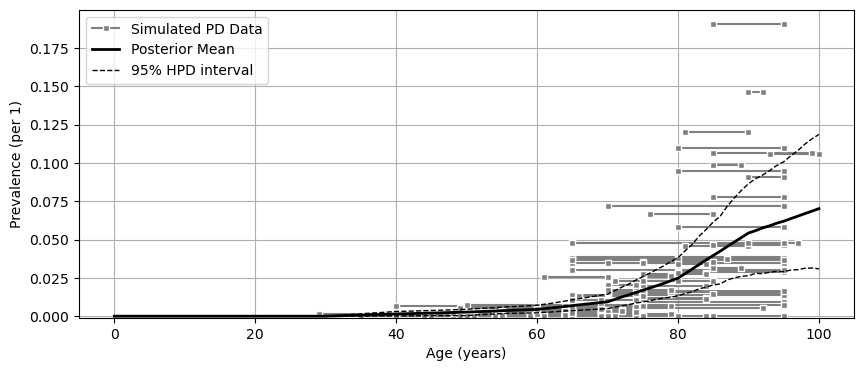

[SAVE] results/ETH/European_ancestry/Late-dry/age_curve_2021_European_ancestry_Late-dry.csv
[RUN] Group=European_ancestry | Stage=Early (./data_ready/input_data/ETH/European/joined_input_data_European_ancestry_Early.csv)
Standard errors replaced: 0
Effective sample sizes filled: 0


INFO:pipeline:  ▶ pm.find_MAP() 수행 중...


Multiprocess sampling (8 chains in 4 jobs)
INFO:pymc:Multiprocess sampling (8 chains in 4 jobs)
CompoundStep
INFO:pymc:CompoundStep
>Metropolis: [gamma_p]
INFO:pymc:>Metropolis: [gamma_p]
>Metropolis: [sigma_alpha_p_0_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_0_z]
>Metropolis: [sigma_alpha_p_1_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_1_z]
>Metropolis: [sigma_alpha_p_2_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_2_z]
>Metropolis: [sigma_alpha_p_3_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_3_z]
>Metropolis: [alpha_p_100]
INFO:pymc:>Metropolis: [alpha_p_100]
>Metropolis: [alpha_p_102]
INFO:pymc:>Metropolis: [alpha_p_102]
>Metropolis: [alpha_p_73]
INFO:pymc:>Metropolis: [alpha_p_73]
>Metropolis: [alpha_p_80]
INFO:pymc:>Metropolis: [alpha_p_80]
>Metropolis: [alpha_p_81]
INFO:pymc:>Metropolis: [alpha_p_81]
>Metropolis: [alpha_p_84]
INFO:pymc:>Metropolis: [alpha_p_84]
>Metropolis: [alpha_p_90]
INFO:pymc:>Metropolis: [alpha_p_90]
>Metropolis: [alpha_p_92]
INFO:pymc:>Metropolis: [alpha_p_92]
>Metropo

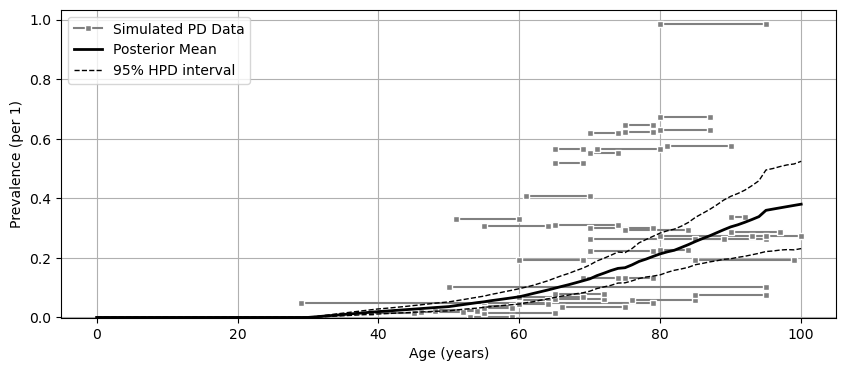

[SAVE] results/ETH/European_ancestry/Early/age_curve_2021_European_ancestry_Early.csv
[RUN] Group=European_ancestry | Stage=Intermediate (./data_ready/input_data/ETH/European/joined_input_data_European_ancestry_Intermediate.csv)
Standard errors replaced: 0
Effective sample sizes filled: 0


INFO:pipeline:  ▶ pm.find_MAP() 수행 중...


Multiprocess sampling (8 chains in 4 jobs)
INFO:pymc:Multiprocess sampling (8 chains in 4 jobs)
CompoundStep
INFO:pymc:CompoundStep
>Metropolis: [gamma_p]
INFO:pymc:>Metropolis: [gamma_p]
>Metropolis: [sigma_alpha_p_0_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_0_z]
>Metropolis: [sigma_alpha_p_1_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_1_z]
>Metropolis: [sigma_alpha_p_2_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_2_z]
>Metropolis: [sigma_alpha_p_3_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_3_z]
>Metropolis: [alpha_p_70]
INFO:pymc:>Metropolis: [alpha_p_70]
>Metropolis: [alpha_p_71]
INFO:pymc:>Metropolis: [alpha_p_71]
>Metropolis: [alpha_p_100]
INFO:pymc:>Metropolis: [alpha_p_100]
>Metropolis: [alpha_p_102]
INFO:pymc:>Metropolis: [alpha_p_102]
>Metropolis: [alpha_p_73]
INFO:pymc:>Metropolis: [alpha_p_73]
>Metropolis: [alpha_p_80]
INFO:pymc:>Metropolis: [alpha_p_80]
>Metropolis: [alpha_p_81]
INFO:pymc:>Metropolis: [alpha_p_81]
>Metropolis: [alpha_p_84]
INFO:pymc:>Metropolis: [alpha_p_84]
>Metropo

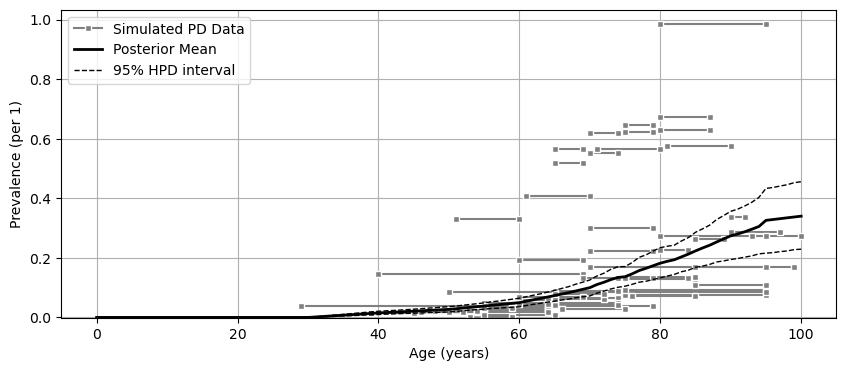

[SAVE] results/ETH/European_ancestry/Intermediate/age_curve_2021_European_ancestry_Intermediate.csv
[RUN] Group=European_ancestry | Stage=Late-wet (./data_ready/input_data/ETH/European/joined_input_data_European_ancestry_Late-wet.csv)
Standard errors replaced: 0
Effective sample sizes filled: 0


INFO:pipeline:  ▶ pm.find_MAP() 수행 중...


Multiprocess sampling (8 chains in 4 jobs)
INFO:pymc:Multiprocess sampling (8 chains in 4 jobs)
CompoundStep
INFO:pymc:CompoundStep
>Metropolis: [gamma_p]
INFO:pymc:>Metropolis: [gamma_p]
>Metropolis: [sigma_alpha_p_0_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_0_z]
>Metropolis: [sigma_alpha_p_1_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_1_z]
>Metropolis: [sigma_alpha_p_2_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_2_z]
>Metropolis: [sigma_alpha_p_3_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_3_z]
>Metropolis: [alpha_p_31]
INFO:pymc:>Metropolis: [alpha_p_31]
>Metropolis: [alpha_p_56]
INFO:pymc:>Metropolis: [alpha_p_56]
>Metropolis: [alpha_p_58]
INFO:pymc:>Metropolis: [alpha_p_58]
>Metropolis: [alpha_p_64]
INFO:pymc:>Metropolis: [alpha_p_64]
>Metropolis: [alpha_p_70]
INFO:pymc:>Metropolis: [alpha_p_70]
>Metropolis: [alpha_p_71]
INFO:pymc:>Metropolis: [alpha_p_71]
>Metropolis: [alpha_p_100]
INFO:pymc:>Metropolis: [alpha_p_100]
>Metropolis: [alpha_p_102]
INFO:pymc:>Metropolis: [alpha_p_102]
>Metropo

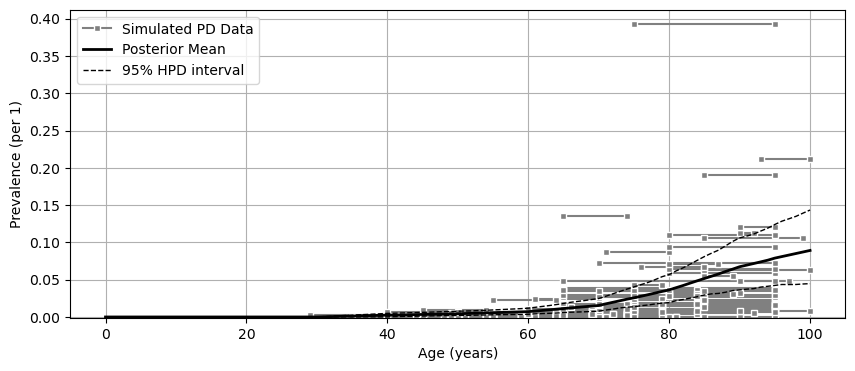

[SAVE] results/ETH/European_ancestry/Late-wet/age_curve_2021_European_ancestry_Late-wet.csv
[RUN] Group=Hispanic | Stage=Intermediate (./data_ready/input_data/ETH/Hispanic/joined_input_data_Hispanic_Intermediate.csv)
Standard errors replaced: 0
Effective sample sizes filled: 0


INFO:pipeline:  ▶ pm.find_MAP() 수행 중...


Multiprocess sampling (8 chains in 4 jobs)
INFO:pymc:Multiprocess sampling (8 chains in 4 jobs)
CompoundStep
INFO:pymc:CompoundStep
>Metropolis: [gamma_p]
INFO:pymc:>Metropolis: [gamma_p]
>Metropolis: [sigma_alpha_p_0_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_0_z]
>Metropolis: [sigma_alpha_p_1_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_1_z]
>Metropolis: [sigma_alpha_p_2_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_2_z]
>Metropolis: [sigma_alpha_p_3_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_3_z]
>Metropolis: [beta_p_x_lpa]
INFO:pymc:>Metropolis: [beta_p_x_lpa]
>Metropolis: [beta_p_x_sev]
INFO:pymc:>Metropolis: [beta_p_x_sev]
>Metropolis: [beta_p_x_sex]
INFO:pymc:>Metropolis: [beta_p_x_sex]
>Metropolis: [eta_p]
INFO:pymc:>Metropolis: [eta_p]
Sampling 8 chains for 1_000 tune and 4_000 draw iterations (8_000 + 32_000 draws total) took 27 seconds.
INFO:pymc:Sampling 8 chains for 1_000 tune and 4_000 draw iterations (8_000 + 32_000 draws total) took 27 seconds.
The rhat statistic is larger than 1.01

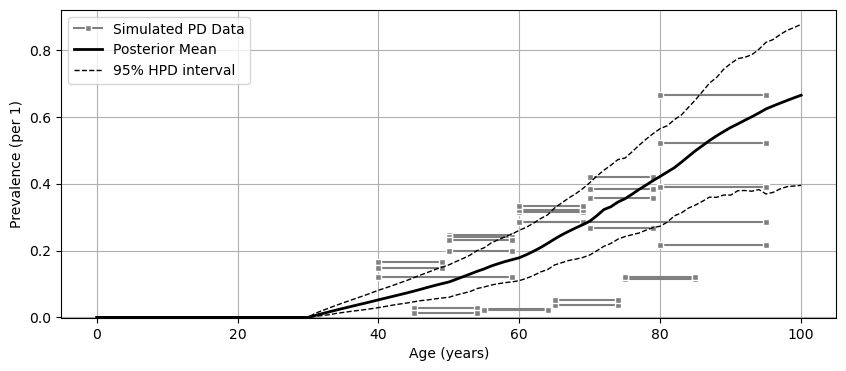

[SAVE] results/ETH/Hispanic/Intermediate/age_curve_2021_Hispanic_Intermediate.csv
[RUN] Group=Hispanic | Stage=Early (./data_ready/input_data/ETH/Hispanic/joined_input_data_Hispanic_Early.csv)
Standard errors replaced: 0
Effective sample sizes filled: 0


INFO:pipeline:  ▶ pm.find_MAP() 수행 중...


Multiprocess sampling (8 chains in 4 jobs)
INFO:pymc:Multiprocess sampling (8 chains in 4 jobs)
CompoundStep
INFO:pymc:CompoundStep
>Metropolis: [gamma_p]
INFO:pymc:>Metropolis: [gamma_p]
>Metropolis: [sigma_alpha_p_0_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_0_z]
>Metropolis: [sigma_alpha_p_1_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_1_z]
>Metropolis: [sigma_alpha_p_2_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_2_z]
>Metropolis: [sigma_alpha_p_3_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_3_z]
>Metropolis: [beta_p_x_lpa]
INFO:pymc:>Metropolis: [beta_p_x_lpa]
>Metropolis: [beta_p_x_sev]
INFO:pymc:>Metropolis: [beta_p_x_sev]
>Metropolis: [beta_p_x_sex]
INFO:pymc:>Metropolis: [beta_p_x_sex]
>Metropolis: [eta_p]
INFO:pymc:>Metropolis: [eta_p]
Sampling 8 chains for 1_000 tune and 4_000 draw iterations (8_000 + 32_000 draws total) took 20 seconds.
INFO:pymc:Sampling 8 chains for 1_000 tune and 4_000 draw iterations (8_000 + 32_000 draws total) took 20 seconds.
The rhat statistic is larger than 1.01

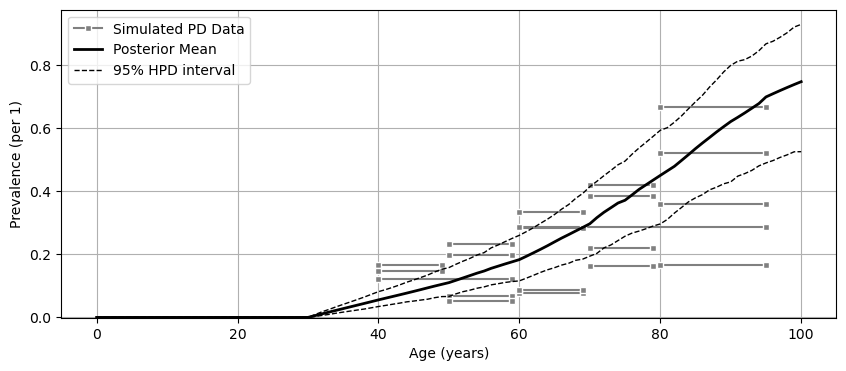

[SAVE] results/ETH/Hispanic/Early/age_curve_2021_Hispanic_Early.csv
[RUN] Group=Hispanic | Stage=Late-wet (./data_ready/input_data/ETH/Hispanic/joined_input_data_Hispanic_Late-wet.csv)
Standard errors replaced: 0
Effective sample sizes filled: 0


INFO:pipeline:  ▶ pm.find_MAP() 수행 중...


Multiprocess sampling (8 chains in 4 jobs)
INFO:pymc:Multiprocess sampling (8 chains in 4 jobs)
CompoundStep
INFO:pymc:CompoundStep
>Metropolis: [gamma_p]
INFO:pymc:>Metropolis: [gamma_p]
>Metropolis: [sigma_alpha_p_0_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_0_z]
>Metropolis: [sigma_alpha_p_1_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_1_z]
>Metropolis: [sigma_alpha_p_2_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_2_z]
>Metropolis: [sigma_alpha_p_3_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_3_z]
>Metropolis: [beta_p_x_lpa]
INFO:pymc:>Metropolis: [beta_p_x_lpa]
>Metropolis: [beta_p_x_sev]
INFO:pymc:>Metropolis: [beta_p_x_sev]
>Metropolis: [beta_p_x_sex]
INFO:pymc:>Metropolis: [beta_p_x_sex]
>Metropolis: [eta_p]
INFO:pymc:>Metropolis: [eta_p]
Sampling 8 chains for 1_000 tune and 4_000 draw iterations (8_000 + 32_000 draws total) took 28 seconds.
INFO:pymc:Sampling 8 chains for 1_000 tune and 4_000 draw iterations (8_000 + 32_000 draws total) took 28 seconds.
The rhat statistic is larger than 1.01

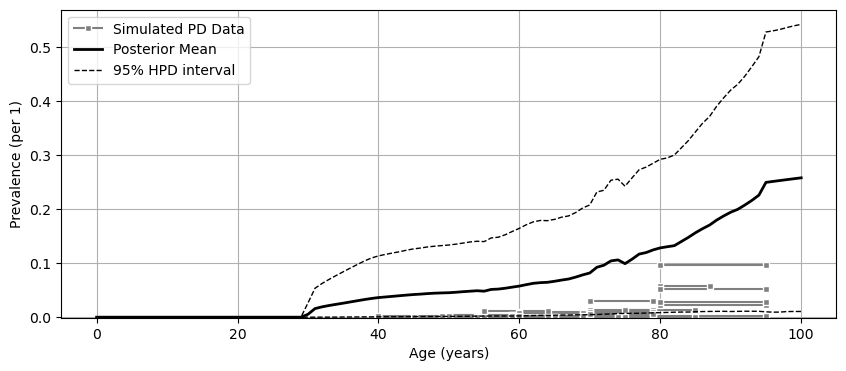

[SAVE] results/ETH/Hispanic/Late-wet/age_curve_2021_Hispanic_Late-wet.csv
[RUN] Group=Hispanic | Stage=Late-dry (./data_ready/input_data/ETH/Hispanic/joined_input_data_Hispanic_Late-dry.csv)
Standard errors replaced: 0
Effective sample sizes filled: 0


INFO:pipeline:  ▶ pm.find_MAP() 수행 중...


Multiprocess sampling (8 chains in 4 jobs)
INFO:pymc:Multiprocess sampling (8 chains in 4 jobs)
CompoundStep
INFO:pymc:CompoundStep
>Metropolis: [gamma_p]
INFO:pymc:>Metropolis: [gamma_p]
>Metropolis: [sigma_alpha_p_0_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_0_z]
>Metropolis: [sigma_alpha_p_1_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_1_z]
>Metropolis: [sigma_alpha_p_2_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_2_z]
>Metropolis: [sigma_alpha_p_3_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_3_z]
>Metropolis: [beta_p_x_lpa]
INFO:pymc:>Metropolis: [beta_p_x_lpa]
>Metropolis: [beta_p_x_sev]
INFO:pymc:>Metropolis: [beta_p_x_sev]
>Metropolis: [beta_p_x_sex]
INFO:pymc:>Metropolis: [beta_p_x_sex]
>Metropolis: [eta_p]
INFO:pymc:>Metropolis: [eta_p]
Sampling 8 chains for 1_000 tune and 4_000 draw iterations (8_000 + 32_000 draws total) took 23 seconds.
INFO:pymc:Sampling 8 chains for 1_000 tune and 4_000 draw iterations (8_000 + 32_000 draws total) took 23 seconds.
The rhat statistic is larger than 1.01

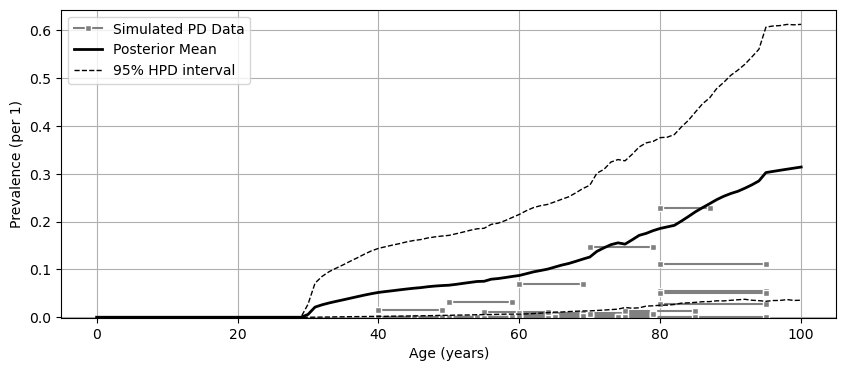

[SAVE] results/ETH/Hispanic/Late-dry/age_curve_2021_Hispanic_Late-dry.csv
[RUN] Group=Asian_ancestry | Stage=Early (./data_ready/input_data/ETH/Asian/joined_input_data_Asian_ancestry_Early.csv)
Standard errors replaced: 0
Effective sample sizes filled: 0


INFO:pipeline:  ▶ pm.find_MAP() 수행 중...


Multiprocess sampling (8 chains in 4 jobs)
INFO:pymc:Multiprocess sampling (8 chains in 4 jobs)
CompoundStep
INFO:pymc:CompoundStep
>Metropolis: [gamma_p]
INFO:pymc:>Metropolis: [gamma_p]
>Metropolis: [sigma_alpha_p_0_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_0_z]
>Metropolis: [sigma_alpha_p_1_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_1_z]
>Metropolis: [sigma_alpha_p_2_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_2_z]
>Metropolis: [sigma_alpha_p_3_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_3_z]
>Metropolis: [alpha_p_31]
INFO:pymc:>Metropolis: [alpha_p_31]
>Metropolis: [alpha_p_56]
INFO:pymc:>Metropolis: [alpha_p_56]
>Metropolis: [alpha_p_62]
INFO:pymc:>Metropolis: [alpha_p_62]
>Metropolis: [alpha_p_64]
INFO:pymc:>Metropolis: [alpha_p_64]
>Metropolis: [alpha_p_65]
INFO:pymc:>Metropolis: [alpha_p_65]
>Metropolis: [alpha_p_67]
INFO:pymc:>Metropolis: [alpha_p_67]
>Metropolis: [alpha_p_68]
INFO:pymc:>Metropolis: [alpha_p_68]
>Metropolis: [alpha_p_69]
INFO:pymc:>Metropolis: [alpha_p_69]
>Metropolis:

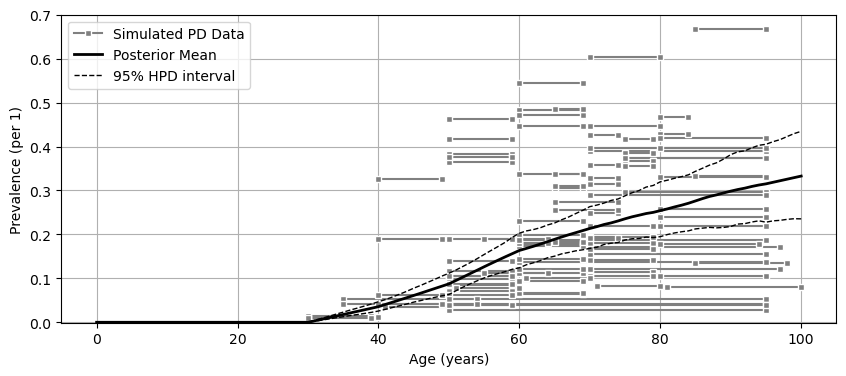

[SAVE] results/ETH/Asian_ancestry/Early/age_curve_2021_Asian_ancestry_Early.csv
[RUN] Group=Asian_ancestry | Stage=Late-wet (./data_ready/input_data/ETH/Asian/joined_input_data_Asian_ancestry_Late-wet.csv)
Standard errors replaced: 0
Effective sample sizes filled: 0


INFO:pipeline:  ▶ pm.find_MAP() 수행 중...


Multiprocess sampling (8 chains in 4 jobs)
INFO:pymc:Multiprocess sampling (8 chains in 4 jobs)
CompoundStep
INFO:pymc:CompoundStep
>Metropolis: [gamma_p]
INFO:pymc:>Metropolis: [gamma_p]
>Metropolis: [sigma_alpha_p_0_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_0_z]
>Metropolis: [sigma_alpha_p_1_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_1_z]
>Metropolis: [sigma_alpha_p_2_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_2_z]
>Metropolis: [sigma_alpha_p_3_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_3_z]
>Metropolis: [alpha_p_31]
INFO:pymc:>Metropolis: [alpha_p_31]
>Metropolis: [alpha_p_56]
INFO:pymc:>Metropolis: [alpha_p_56]
>Metropolis: [alpha_p_62]
INFO:pymc:>Metropolis: [alpha_p_62]
>Metropolis: [alpha_p_64]
INFO:pymc:>Metropolis: [alpha_p_64]
>Metropolis: [alpha_p_65]
INFO:pymc:>Metropolis: [alpha_p_65]
>Metropolis: [alpha_p_67]
INFO:pymc:>Metropolis: [alpha_p_67]
>Metropolis: [alpha_p_68]
INFO:pymc:>Metropolis: [alpha_p_68]
>Metropolis: [alpha_p_69]
INFO:pymc:>Metropolis: [alpha_p_69]
>Metropolis:

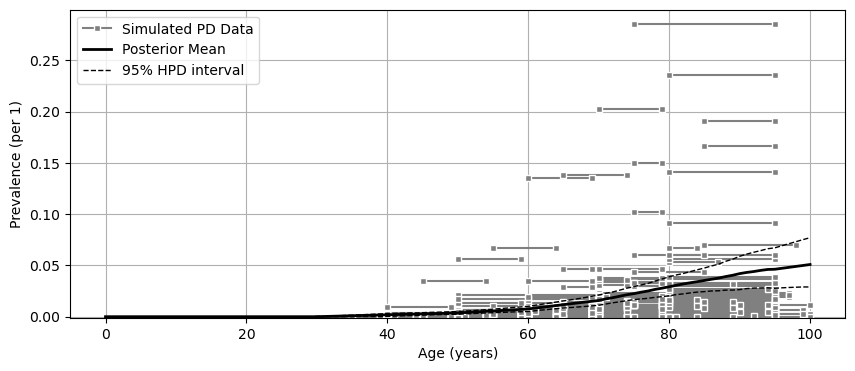

[SAVE] results/ETH/Asian_ancestry/Late-wet/age_curve_2021_Asian_ancestry_Late-wet.csv
[RUN] Group=Asian_ancestry | Stage=Late-dry (./data_ready/input_data/ETH/Asian/joined_input_data_Asian_ancestry_Late-dry.csv)
Standard errors replaced: 0
Effective sample sizes filled: 0


INFO:pipeline:  ▶ pm.find_MAP() 수행 중...


Multiprocess sampling (8 chains in 4 jobs)
INFO:pymc:Multiprocess sampling (8 chains in 4 jobs)
CompoundStep
INFO:pymc:CompoundStep
>Metropolis: [gamma_p]
INFO:pymc:>Metropolis: [gamma_p]
>Metropolis: [sigma_alpha_p_0_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_0_z]
>Metropolis: [sigma_alpha_p_1_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_1_z]
>Metropolis: [sigma_alpha_p_2_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_2_z]
>Metropolis: [sigma_alpha_p_3_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_3_z]
>Metropolis: [alpha_p_31]
INFO:pymc:>Metropolis: [alpha_p_31]
>Metropolis: [alpha_p_56]
INFO:pymc:>Metropolis: [alpha_p_56]
>Metropolis: [alpha_p_62]
INFO:pymc:>Metropolis: [alpha_p_62]
>Metropolis: [alpha_p_64]
INFO:pymc:>Metropolis: [alpha_p_64]
>Metropolis: [alpha_p_65]
INFO:pymc:>Metropolis: [alpha_p_65]
>Metropolis: [alpha_p_67]
INFO:pymc:>Metropolis: [alpha_p_67]
>Metropolis: [alpha_p_68]
INFO:pymc:>Metropolis: [alpha_p_68]
>Metropolis: [alpha_p_69]
INFO:pymc:>Metropolis: [alpha_p_69]
>Metropolis:

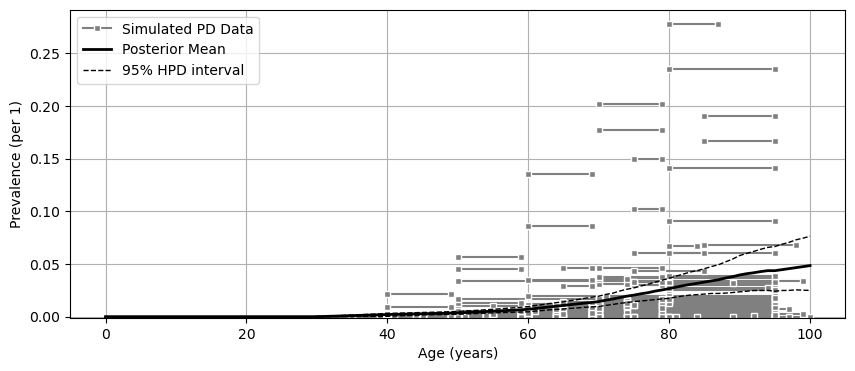

[SAVE] results/ETH/Asian_ancestry/Late-dry/age_curve_2021_Asian_ancestry_Late-dry.csv
[RUN] Group=Asian_ancestry | Stage=Intermediate (./data_ready/input_data/ETH/Asian/joined_input_data_Asian_ancestry_Intermediate.csv)
Standard errors replaced: 0
Effective sample sizes filled: 0


INFO:pipeline:  ▶ pm.find_MAP() 수행 중...


Multiprocess sampling (8 chains in 4 jobs)
INFO:pymc:Multiprocess sampling (8 chains in 4 jobs)
CompoundStep
INFO:pymc:CompoundStep
>Metropolis: [gamma_p]
INFO:pymc:>Metropolis: [gamma_p]
>Metropolis: [sigma_alpha_p_0_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_0_z]
>Metropolis: [sigma_alpha_p_1_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_1_z]
>Metropolis: [sigma_alpha_p_2_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_2_z]
>Metropolis: [sigma_alpha_p_3_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_3_z]
>Metropolis: [alpha_p_31]
INFO:pymc:>Metropolis: [alpha_p_31]
>Metropolis: [alpha_p_56]
INFO:pymc:>Metropolis: [alpha_p_56]
>Metropolis: [alpha_p_62]
INFO:pymc:>Metropolis: [alpha_p_62]
>Metropolis: [alpha_p_64]
INFO:pymc:>Metropolis: [alpha_p_64]
>Metropolis: [alpha_p_65]
INFO:pymc:>Metropolis: [alpha_p_65]
>Metropolis: [alpha_p_67]
INFO:pymc:>Metropolis: [alpha_p_67]
>Metropolis: [alpha_p_68]
INFO:pymc:>Metropolis: [alpha_p_68]
>Metropolis: [alpha_p_69]
INFO:pymc:>Metropolis: [alpha_p_69]
>Metropolis:

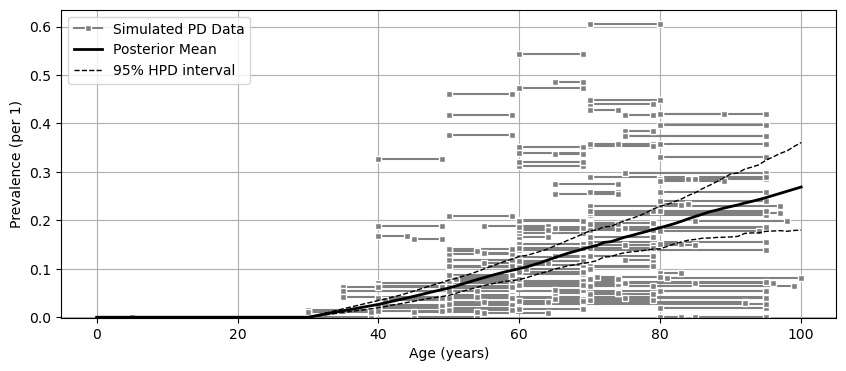

[SAVE] results/ETH/Asian_ancestry/Intermediate/age_curve_2021_Asian_ancestry_Intermediate.csv
[DONE] All ETH runs finished.


In [6]:
import os, re, numpy as np, pandas as pd

def slugify(s: str) -> str:
    # 공백/슬래시 등 파일명 안전하게 변환
    s = s.strip()
    s = s.replace(" to ", "-to-")  # 특별 케이스 보존
    s = re.sub(r"\s+", "-", s)     # 공백→하이픈
    s = re.sub(r"[^A-Za-z0-9._-]+", "", s)  # 안전 문자만
    return s

def parse_group_stage(path: str):
    """
    파일명 예:
      joined_input_data_African_ancestry_Late-dry.csv
      joined_input_data_African_ancestry_Early to intermediate.csv
      joined_input_data_European_ancestry_Intermediate.csv
      joined_input_data_Hispanic_Early.csv
      joined_input_data_Asian_ancestry_Late-wet.csv
    규칙: 'joined_input_data_' 이후 마지막 '_' 앞까지 = group, 마지막 '_' 뒤 = stage
    """
    base = os.path.basename(path)
    name = base[:-4] if base.lower().endswith(".csv") else base
    if not name.startswith("joined_input_data_"):
        raise ValueError(f"Unexpected filename: {base}")
    tail = name[len("joined_input_data_"):]           # e.g., 'African_ancestry_Late-dry'
    split_idx = tail.rfind('_')
    if split_idx == -1:
        raise ValueError(f"Cannot parse group/stage from: {base}")
    group = tail[:split_idx]                          # e.g., 'African_ancestry'
    stage = tail[split_idx+1:]                        # e.g., 'Late-dry' or 'Early to intermediate'
    return group, stage

# ------------------ 메인 루프 ------------------
dir_path = './data_ready/input_data/ETH'
csv_files = list_all_csv_files(dir_path)  # 기존 함수 사용

YEAR_FOR_AGE_CURVE = 2021
YEARS_FOR_WORLD = list(range(1990, 2022))

for input_data_path in csv_files:
    group, stage = parse_group_stage(input_data_path)
    group_slug = slugify(group)
    stage_slug = slugify(stage)

    print(f"[RUN] Group={group} | Stage={stage} ({input_data_path})")

    # 결과 폴더: results/ETH/<group>/<stage>/
    out_dir = os.path.join("results", "ETH", group_slug, stage_slug)
    os.makedirs(out_dir, exist_ok=True)

    # ----- 파이프라인 -----
    pm_model = pipeline.initiliaze_pipeline(
        input_data_path=input_data_path,
        output_template_path=output_template_path,
        parameters_path=parameters_path,
        hierarchy_path=hierarchy_path,
        detailed_pop_path=detailed_pop_path,
        verbose=False
    )

    rate_type = 'neg_binom'
    pipeline.generate_pymc_objects(pm_model, rate_type=rate_type, include_covariates=True)
    map_estimate = pipeline.return_map_estimate(pm_model=pm_model, verbose=False)
    idata = pipeline.return_idata(
        pm_model     = pm_model,
        map_estimate = map_estimate,
        draws        = 4000,
        tune         = 1000,
        chains       = 8,
        cores        = 4,
        target_accept= 0.9,
        max_treedepth= 10,
        use_advi     = False,
        use_metropolis=True,
        verbose=False
    )

    # ----- 연령별 곡선 예측 (YEAR_FOR_AGE_CURVE) -----
    pred = pipeline.predict_for(
        pm_model            = pm_model,
        idata               = idata,
        root_area           = 'Global',
        root_sex            = 'Both',
        root_year           = 'all',
        location_id         = 1,
        sex_name            = 'Both',
        year_id             = YEAR_FOR_AGE_CURVE,
        population_weighted = True,
        lower               = 0.0,
        upper               = 1.0,
        include_covariates  = True,
        return_scalar       = False
    )
    pipeline.visualize_pred(pred, pm_model.shared_data["data"])

    # 요약 통계 → CSV 저장
    mean_vals  = pred.mean(axis=0)
    lower_vals = np.percentile(pred,  2.5, axis=0)
    upper_vals = np.percentile(pred, 97.5, axis=0)

    ages = np.arange(pred.shape[1])  # 0..100 가정
    df_age = pd.DataFrame({
        'mean'     : mean_vals,
        'lower_ci' : lower_vals,
        'upper_ci' : upper_vals
    }, index=ages).rename_axis('age')

    age_csv = os.path.join(out_dir, f"age_curve_{YEAR_FOR_AGE_CURVE}_{group_slug}_{stage_slug}.csv")
    df_age.to_csv(age_csv)
    print(f"[SAVE] {age_csv}")

print("[DONE] All ETH runs finished.")
